In [1]:
import time

start_time = time.time()
print(f"Start time recorded: {start_time}")

Start time recorded: 1767067762.67755


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/02_finetune_with_crf_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [2]:
# @markdown package install
do = False # @param{type:"boolean"}
if do:
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq

## ⭐ Setup
You must run all codes under this category.

In [3]:
if do:
    !git clone https://github.com/phonchi/CryoParticleSegment.git

    !wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
    !wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
    !wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
    # !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

    !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/weight_view_02/trainer.py

In [4]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

> #### ⚠ Notice
>
> You need to restart the kernel after the compilation step. Additionally, if your GPU architecture differs, you may need to modify the file at `/content/CryoParticleSegment/Modeling/CRF_main/setup.py`. (We attempt to detect the GPU configuration automatically, so this step is usually not necessary.)
> Furthermore, depending on the number of classes and other parameters, you may encounter an error that requires adjusting the file at `/content/CryoParticleSegment/Modeling/CRF_main/src/PermutohedralFiltering/source/gpu/LatticeFilter.cu`:
>
> 1. Note the `pd` and `vd` values from the error message.
> 2. Add an `else if (pd == ? && vd == ?)` block.
> 3. Within that block, insert the following line, replacing `pd` and `vd` with the specific values:
>
>    ```cpp
>    latticeFilterGPU<pd, vd>(output_tensor, input_tensor, positions, num_super_pixels, backward);
>    ```
> 4. Recompile using `setup.py`.

In [5]:
if do:
    #!git clone https://github.com/netw0rkf10w/CRF.git
    %cd CryoParticleSegment/Modeling/CRF_main
    !python setup.py clean --all
    !rm -rf build/
    !python setup.py build_ext --inplace --force
    !python setup.py install

    crf_path = os.path.join(os.getcwd(), 'CRF')
    if crf_path not in sys.path:
        sys.path.insert(0, crf_path)

    print(f"Added {crf_path} to the Python path.")

In [6]:
%cd /content/

/content


### ✅ Directory Settings

In [7]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [8]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---

LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!cp -r {DENOISED_IMAGE_DIR} /content/denoised_image_dir
DENOISED_IMAGE_DIR = "/content/denoised_image_dir"

In [11]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
        if dnzd_pw == True:
            !cp -r {DENOISED_IMAGE_DIR} /content/denoised_image_dir
            DENOISED_IMAGE_DIR = "/content/denoised_image_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ✅ Packages Handling

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

In [13]:
from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched, collate_fn
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [14]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [15]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 100
BATCH = 2
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [17]:
crop = transforms.CenterCrop(3840)

In [18]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [19]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [20]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [21]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Convcrf wtih FCN finetuned on cryoem

## The model

### ✅ Model

Currently, we only test `fw` and `mf` solver as described in the paper. You could set `use_unary_only` to `True` to obtained CD-CRF, while setting `False` return to traditional CRF.

In [22]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = False # @param {type:"boolean"}
loss = "dice" # @param {type:"string"}

In [23]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [24]:
# @markdown input the dir_name where you store the model in best notebook  01
dir_name = "unet_eb5_dice" # @param {type:"string"}
CHECKPOINT_PATH = os.path.dirname(RESULT_DIR.rstrip(os.path.sep)) + f"/{dir_name}"

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice/checkpoint39.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice/checkpoint39.pt


In [25]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=use_unary_only)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


In [26]:
params = [
    {'params': model.backbone.parameters(), 'lr': 1e-5},  # Lower learning rate for fine-tuning the backbone
    {'params': crf.parameters(), 'lr': 1e-3}         # Higher learning rate for training the CRF from scratch
]

In [27]:
print(model_post)

ModelWithFWCRF(
  (backbone): UnetPlusPlus(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn1): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (g

In [28]:
from torchinfo import summary
summary(model_post, input_size=(BATCH, 1, 512, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
ModelWithFWCRF                                          [2, 2, 512, 512]          --
├─UnetPlusPlus: 1-1                                     [2, 2, 512, 512]          --
│    └─EfficientNetEncoder: 2-1                         [2, 1, 512, 512]          1,052,672
│    │    └─Conv2d: 3-1                                 [2, 48, 256, 256]         432
│    │    └─BatchNormAct2d: 3-2                         [2, 48, 256, 256]         96
│    │    └─Sequential: 3-3                             --                        27,286,720
│    └─UnetPlusPlusDecoder: 2-2                         [2, 16, 512, 512]         --
│    │    └─ModuleDict: 3-4                             --                        3,569,152
│    └─SegmentationHead: 2-3                            [2, 2, 512, 512]          --
│    │    └─Conv2d: 3-5                                 [2, 2, 512, 512]          290
│    │    └─Identity: 3-6           

In [29]:
import math
if loss == "dice":
    criterion = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "cross_entropy":
    criterion = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
elif loss == "jaccard":
    criterion = smp.losses.JaccardLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Lovasz":
    criterion = smp.losses.LovaszLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Tversky":
    criterion = smp.losses.TverskyLoss(smp.losses.MULTICLASS_MODE, from_logits=True, alpha=0.7, beta=0.3, gamma=1, smooth=0.1)
else:
    print("Loss not supported")
    raise NotImplementedError
optimizer = torch.optim.Adam(params)
#scheduler = ReduceLROnPlateau(optimizer, patience=RLR_PATIENCE, verbose=True)
#scheduler = OneCycleLR(optimizer, max_lr=LR, verbose=True, steps_per_epoch=math.ceil(len(train_dataset)/BATCH), epochs=EPOCHS)

In [30]:
!mkdir -p {RESULT_DIR}

In [31]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

### ✅ Training

In [32]:
# Unet++ eb5 CDCRF fw
Trainer = tqdm_plugin_for_Trainer(CryoEMTrainerWithScheduler)
trainer = Trainer(model_post, train_dataset, criterion, optimizer, DEVICE,
              num_classes = NUM_CLASSES, patience=ES_PATIENCE)

trainer.train(EPOCHS, val_loader=val_loader, batch_size = BATCH,
              ckpt_dir = RESULT_DIR, random_state = random_state)

Epoch   1/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1408
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000064
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000067
tensor([[ 1.0001e+00, -4.4090e-05],
        [-9.0882e-05,  1.0000e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 1.000030
Epoch 1: W1(Appearance) Off_Diag_Mean -> -0.000034
tensor([[ 1.0000e+00, -2.9054e-05],
        [-3.8088e-05,  1.0000e+00]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1546
Iou by Class: [0.87459946 0.6363455 ]
Precision by Class: [0.94614714 0.74370754]
Recall by Class: [0.92041826 0.8150899 ]
Accuracy by Class: [0.8971649 0.8971649]
F1_score by Class: [0.93310547 0.77776426]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.15458920101324716.
Epoch   2/100:


...

Validation score:
  loss : 0.1544
Iou by Class: [0.87643224 0.6360761 ]
Precision by Class: [0.9435083 0.7523501]
Recall by Class: [0.9249706 0.8045244]
Accuracy by Class: [0.89837974 0.89837974]
F1_score by Class: [0.9341475  0.77756304]
No improvement for 14 epoch.
Epoch  23/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1378
Epoch 23: W2(Smoothness) Diag_Mean -> 1.002507
Epoch 23: W2(Smoothness) Off_Diag_Mean -> -0.002496
tensor([[ 1.0127,  0.0076],
        [-0.0126,  0.9924]])
Epoch 23: W1(Appearance) Diag_Mean -> 1.002721
Epoch 23: W1(Appearance) Off_Diag_Mean -> -0.002724
tensor([[ 1.0115,  0.0060],
        [-0.0114,  0.9940]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1541
Iou by Class: [0.8768407  0.63692594]
Precision by Class: [0.943595   0.75332946]
Recall by Class: [0.9253422 0.8047638]
Accuracy by Class: [0.8987222 0.8987222]
F1_score by Class: [0.9343795 0.7781976]
Early stopping


In [45]:
# @title input lines
lines = """
Epoch   1/100:
Training: 100%
 4/4 [00:06<00:00,  1.64s/it, Loss=0.1100]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1408
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000064
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000067
tensor([[ 1.0001e+00, -4.4090e-05],
        [-9.0882e-05,  1.0000e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 1.000030
Epoch 1: W1(Appearance) Off_Diag_Mean -> -0.000034
tensor([[ 1.0000e+00, -2.9054e-05],
        [-3.8088e-05,  1.0000e+00]])
Validation: 100%
 6/6 [00:33<00:00,  5.44s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.87459946 0.6363455 ]
Precision by Class: [0.94614714 0.74370754]
Recall by Class: [0.92041826 0.8150899 ]
Accuracy by Class: [0.8971649 0.8971649]
F1_score by Class: [0.93310547 0.77776426]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.15458920101324716.
Epoch   2/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1022]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1425
Epoch 2: W2(Smoothness) Diag_Mean -> 1.000135
Epoch 2: W2(Smoothness) Off_Diag_Mean -> -0.000142
tensor([[ 1.0004e+00,  9.1299e-05],
        [-3.7552e-04,  9.9990e-01]])
Epoch 2: W1(Appearance) Diag_Mean -> 0.999956
Epoch 2: W1(Appearance) Off_Diag_Mean -> 0.000037
tensor([[ 1.0002e+00,  2.9082e-04],
        [-2.1690e-04,  9.9970e-01]])
Validation: 100%
 6/6 [00:32<00:00,  5.44s/it]
Validation score:
  loss : 0.1540
Iou by Class: [0.875145  0.6376313]
Precision by Class: [0.9463891 0.7447942]
Recall by Class: [0.92079335 0.81589264]
Accuracy by Class: [0.89763445 0.89763445]
F1_score by Class: [0.9334158  0.77872384]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint2.pt
Loss improve to 0.1539559413989385.
Epoch   3/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1758]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1324
Epoch 3: W2(Smoothness) Diag_Mean -> 1.000235
Epoch 3: W2(Smoothness) Off_Diag_Mean -> -0.000246
tensor([[ 9.9942e-01, -1.0645e-03],
        [ 5.7199e-04,  1.0011e+00]])
Epoch 3: W1(Appearance) Diag_Mean -> 1.000025
Epoch 3: W1(Appearance) Off_Diag_Mean -> -0.000036
tensor([[ 9.9919e-01, -8.6844e-04],
        [ 7.9606e-04,  1.0009e+00]])
Validation: 100%
 6/6 [00:32<00:00,  5.47s/it]
Validation score:
  loss : 0.1543
Iou by Class: [0.87575114 0.63632596]
Precision by Class: [0.9445969 0.7489225]
Recall by Class: [0.92316985 0.8088848 ]
Accuracy by Class: [0.8979392 0.8979392]
F1_score by Class: [0.9337604  0.77774966]
No improvement for 1 epoch.
Epoch   4/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1105]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1386
Epoch 4: W2(Smoothness) Diag_Mean -> 1.000349
Epoch 4: W2(Smoothness) Off_Diag_Mean -> -0.000365
tensor([[ 9.9936e-01, -1.3587e-03],
        [ 6.2932e-04,  1.0013e+00]])
Epoch 4: W1(Appearance) Diag_Mean -> 1.000182
Epoch 4: W1(Appearance) Off_Diag_Mean -> -0.000197
tensor([[ 9.9909e-01, -1.2872e-03],
        [ 8.9267e-04,  1.0013e+00]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1536
Iou by Class: [0.87618035 0.63796335]
Precision by Class: [0.94524896 0.7491258 ]
Recall by Class: [0.9230243 0.811294 ]
Accuracy by Class: [0.89835757 0.89835757]
F1_score by Class: [0.9340043 0.7789715]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint4.pt
Loss improve to 0.15358815093835196.
Epoch   5/100:
Training: 100%
 4/4 [00:06<00:00,  1.56s/it, Loss=0.1373]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1387
Epoch 5: W2(Smoothness) Diag_Mean -> 1.000446
Epoch 5: W2(Smoothness) Off_Diag_Mean -> -0.000466
tensor([[ 1.0001e+00, -7.7371e-04],
        [-1.5926e-04,  1.0008e+00]])
Epoch 5: W1(Appearance) Diag_Mean -> 1.000320
Epoch 5: W1(Appearance) Off_Diag_Mean -> -0.000340
tensor([[ 9.9984e-01, -8.1572e-04],
        [ 1.3636e-04,  1.0008e+00]])
Validation: 100%
 6/6 [00:33<00:00,  5.55s/it]
Validation score:
  loss : 0.1530
Iou by Class: [0.8765988 0.639575 ]
Precision by Class: [0.94589907 0.74930185]
Recall by Class: [0.92286885 0.81369436]
Accuracy by Class: [0.89876646 0.89876646]
F1_score by Class: [0.93424207 0.78017163]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint5.pt
Loss improve to 0.15295196076234183.
Epoch   6/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.2094]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1455
Epoch 6: W2(Smoothness) Diag_Mean -> 1.000528
Epoch 6: W2(Smoothness) Off_Diag_Mean -> -0.000551
tensor([[ 9.9995e-01, -1.1287e-03],
        [ 2.7214e-05,  1.0011e+00]])
Epoch 6: W1(Appearance) Diag_Mean -> 1.000406
Epoch 6: W1(Appearance) Off_Diag_Mean -> -0.000428
tensor([[ 9.9961e-01, -1.2189e-03],
        [ 3.6216e-04,  1.0012e+00]])
Validation: 100%
 6/6 [00:32<00:00,  5.50s/it]
Validation score:
  loss : 0.1528
Iou by Class: [0.877234   0.63971716]
Precision by Class: [0.94514763 0.75208557]
Recall by Class: [0.9242905  0.81066525]
Accuracy by Class: [0.89920545 0.89920545]
F1_score by Class: [0.9346026 0.7802775]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint6.pt
Loss improve to 0.15276043117046356.
Epoch   7/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1013]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1252
Epoch 7: W2(Smoothness) Diag_Mean -> 1.000650
Epoch 7: W2(Smoothness) Off_Diag_Mean -> -0.000676
tensor([[ 9.9992e-01, -1.4031e-03],
        [ 5.1726e-05,  1.0014e+00]])
Epoch 7: W1(Appearance) Diag_Mean -> 1.000498
Epoch 7: W1(Appearance) Off_Diag_Mean -> -0.000523
tensor([[ 9.9951e-01, -1.5096e-03],
        [ 4.6343e-04,  1.0015e+00]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1524
Iou by Class: [0.8771465 0.6409707]
Precision by Class: [0.9462119  0.75030327]
Recall by Class: [0.923178  0.8147707]
Accuracy by Class: [0.89924496 0.89924496]
F1_score by Class: [0.934553  0.7812092]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint7.pt
Loss improve to 0.15236644943555197.
Epoch   8/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1261]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1503
Epoch 8: W2(Smoothness) Diag_Mean -> 1.000793
Epoch 8: W2(Smoothness) Off_Diag_Mean -> -0.000821
tensor([[ 1.0007e+00, -9.0502e-04],
        [-7.3764e-04,  1.0009e+00]])
Epoch 8: W1(Appearance) Diag_Mean -> 1.000573
Epoch 8: W1(Appearance) Off_Diag_Mean -> -0.000601
tensor([[ 1.0002e+00, -9.8125e-04],
        [-2.1999e-04,  1.0010e+00]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1523
Iou by Class: [0.8769597 0.6413026]
Precision by Class: [0.9467188  0.74908406]
Recall by Class: [0.9224893 0.8167516]
Accuracy by Class: [0.8991456 0.8991456]
F1_score by Class: [0.934447  0.7814557]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint8.pt
Loss improve to 0.15231521427631378.
Epoch   9/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1344]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1391
Epoch 9: W2(Smoothness) Diag_Mean -> 1.000943
Epoch 9: W2(Smoothness) Off_Diag_Mean -> -0.000973
tensor([[ 1.0016e+00, -3.2585e-04],
        [-1.6210e-03,  1.0003e+00]])
Epoch 9: W1(Appearance) Diag_Mean -> 1.000674
Epoch 9: W1(Appearance) Off_Diag_Mean -> -0.000704
tensor([[ 1.0010e+00, -4.0431e-04],
        [-1.0032e-03,  1.0004e+00]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1526
Iou by Class: [0.87643415 0.64104813]
Precision by Class: [0.94724274 0.74696875]
Recall by Class: [0.9214115 0.818866 ]
Accuracy by Class: [0.8987726 0.8987726]
F1_score by Class: [0.93414867 0.78126675]
No improvement for 1 epoch.
Epoch  10/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1755]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1334
Epoch 10: W2(Smoothness) Diag_Mean -> 1.001089
Epoch 10: W2(Smoothness) Off_Diag_Mean -> -0.001116
tensor([[ 1.0030e+00,  8.1269e-04],
        [-3.0455e-03,  9.9916e-01]])
Epoch 10: W1(Appearance) Diag_Mean -> 1.000755
Epoch 10: W1(Appearance) Off_Diag_Mean -> -0.000783
tensor([[ 1.0023e+00,  7.5806e-04],
        [-2.3233e-03,  9.9922e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1523
Iou by Class: [0.8759148 0.6421574]
Precision by Class: [0.94881153 0.74347705]
Recall by Class: [0.9193598  0.82493335]
Accuracy by Class: [0.89851326 0.89851326]
F1_score by Class: [0.9338535  0.78208995]
No improvement for 2 epoch.
Epoch  11/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1071]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1261
Epoch 11: W2(Smoothness) Diag_Mean -> 1.001210
Epoch 11: W2(Smoothness) Off_Diag_Mean -> -0.001230
tensor([[ 1.0049,  0.0025],
        [-0.0049,  0.9975]])
Epoch 11: W1(Appearance) Diag_Mean -> 1.000905
Epoch 11: W1(Appearance) Off_Diag_Mean -> -0.000926
tensor([[ 1.0041,  0.0023],
        [-0.0041,  0.9977]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1528
Iou by Class: [0.8751784 0.6413941]
Precision by Class: [0.9492351 0.741039 ]
Recall by Class: [0.91815186 0.8266874 ]
Accuracy by Class: [0.89795923 0.89795923]
F1_score by Class: [0.9334348 0.7815236]
No improvement for 3 epoch.
Epoch  12/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1357]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1365
Epoch 12: W2(Smoothness) Diag_Mean -> 1.001331
Epoch 12: W2(Smoothness) Off_Diag_Mean -> -0.001344
tensor([[ 1.0066,  0.0039],
        [-0.0066,  0.9961]])
Epoch 12: W1(Appearance) Diag_Mean -> 1.001080
Epoch 12: W1(Appearance) Off_Diag_Mean -> -0.001093
tensor([[ 1.0058,  0.0036],
        [-0.0058,  0.9964]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1528
Iou by Class: [0.8751965 0.6415405]
Precision by Class: [0.9493241  0.74096775]
Recall by Class: [0.9180886 0.8270193]
Accuracy by Class: [0.8979832 0.8979832]
F1_score by Class: [0.93344504 0.78163224]
No improvement for 4 epoch.
Epoch  13/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1371]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1299
Epoch 13: W2(Smoothness) Diag_Mean -> 1.001461
Epoch 13: W2(Smoothness) Off_Diag_Mean -> -0.001465
tensor([[ 1.0081,  0.0052],
        [-0.0081,  0.9948]])
Epoch 13: W1(Appearance) Diag_Mean -> 1.001322
Epoch 13: W1(Appearance) Off_Diag_Mean -> -0.001327
tensor([[ 1.0073,  0.0047],
        [-0.0073,  0.9953]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1525
Iou by Class: [0.87630254 0.6416111 ]
Precision by Class: [0.9478552 0.7457772]
Recall by Class: [0.92068756 0.82122475]
Accuracy by Class: [0.8987291 0.8987291]
F1_score by Class: [0.93407387 0.78168464]
No improvement for 5 epoch.
Epoch  14/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1541]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1240
Epoch 14: W2(Smoothness) Diag_Mean -> 1.001583
Epoch 14: W2(Smoothness) Off_Diag_Mean -> -0.001587
tensor([[ 1.0089,  0.0057],
        [-0.0089,  0.9943]])
Epoch 14: W1(Appearance) Diag_Mean -> 1.001455
Epoch 14: W1(Appearance) Off_Diag_Mean -> -0.001462
tensor([[ 1.0080,  0.0051],
        [-0.0080,  0.9949]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.8753589 0.6384126]
Precision by Class: [0.94669414 0.74492943]
Recall by Class: [0.9207414 0.8170095]
Accuracy by Class: [0.89784056 0.89784056]
F1_score by Class: [0.9335375  0.77930623]
No improvement for 6 epoch.
Epoch  15/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1265]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1262
Epoch 15: W2(Smoothness) Diag_Mean -> 1.001696
Epoch 15: W2(Smoothness) Off_Diag_Mean -> -0.001695
tensor([[ 1.0097,  0.0064],
        [-0.0097,  0.9936]])
Epoch 15: W1(Appearance) Diag_Mean -> 1.001589
Epoch 15: W1(Appearance) Off_Diag_Mean -> -0.001591
tensor([[ 1.0088,  0.0056],
        [-0.0088,  0.9944]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.8753592 0.6380474]
Precision by Class: [0.94641644 0.7453145 ]
Recall by Class: [0.92100453 0.81594944]
Accuracy by Class: [0.89781153 0.89781153]
F1_score by Class: [0.9335376 0.7790341]
No improvement for 7 epoch.
Epoch  16/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1618]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1338
Epoch 16: W2(Smoothness) Diag_Mean -> 1.001803
Epoch 16: W2(Smoothness) Off_Diag_Mean -> -0.001808
tensor([[ 1.0100,  0.0064],
        [-0.0100,  0.9936]])
Epoch 16: W1(Appearance) Diag_Mean -> 1.001747
Epoch 16: W1(Appearance) Off_Diag_Mean -> -0.001757
tensor([[ 1.0090,  0.0055],
        [-0.0090,  0.9945]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1540
Iou by Class: [0.8750607 0.6378412]
Precision by Class: [0.94666207 0.74419874]
Recall by Class: [0.9204418 0.8169527]
Accuracy by Class: [0.8975946 0.8975946]
F1_score by Class: [0.9333678 0.7788805]
No improvement for 8 epoch.
Epoch  17/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1236]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1341
Epoch 17: W2(Smoothness) Diag_Mean -> 1.001913
Epoch 17: W2(Smoothness) Off_Diag_Mean -> -0.001917
tensor([[ 1.0104,  0.0066],
        [-0.0104,  0.9934]])
Epoch 17: W1(Appearance) Diag_Mean -> 1.001908
Epoch 17: W1(Appearance) Off_Diag_Mean -> -0.001918
tensor([[ 1.0094,  0.0056],
        [-0.0094,  0.9944]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.8765055 0.6372981]
Precision by Class: [0.94431704 0.75135046]
Recall by Class: [0.9242761 0.8076322]
Accuracy by Class: [0.89852464 0.89852464]
F1_score by Class: [0.9341891  0.77847534]
No improvement for 9 epoch.
Epoch  18/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1045]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1343
Epoch 18: W2(Smoothness) Diag_Mean -> 1.002000
Epoch 18: W2(Smoothness) Off_Diag_Mean -> -0.002004
tensor([[ 1.0108,  0.0068],
        [-0.0108,  0.9932]])
Epoch 18: W1(Appearance) Diag_Mean -> 1.002038
Epoch 18: W1(Appearance) Off_Diag_Mean -> -0.002048
tensor([[ 1.0098,  0.0057],
        [-0.0098,  0.9943]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1536
Iou by Class: [0.87702554 0.63793576]
Precision by Class: [0.9440973 0.7530796]
Recall by Class: [0.9250654  0.80666304]
Accuracy by Class: [0.89892566 0.89892566]
F1_score by Class: [0.9344845 0.7789509]
No improvement for 10 epoch.
Epoch  19/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1186]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1294
Epoch 19: W2(Smoothness) Diag_Mean -> 1.002068
Epoch 19: W2(Smoothness) Off_Diag_Mean -> -0.002074
tensor([[ 1.0109,  0.0068],
        [-0.0109,  0.9932]])
Epoch 19: W1(Appearance) Diag_Mean -> 1.002154
Epoch 19: W1(Appearance) Off_Diag_Mean -> -0.002168
tensor([[ 1.0099,  0.0056],
        [-0.0099,  0.9944]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.87848526 0.6364505 ]
Precision by Class: [0.9410772 0.7618158]
Recall by Class: [0.9296178 0.7945584]
Accuracy by Class: [0.8998007 0.8998007]
F1_score by Class: [0.9353124 0.7778427]
No improvement for 11 epoch.
Epoch  20/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1086]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1360
Epoch 20: W2(Smoothness) Diag_Mean -> 1.002157
Epoch 20: W2(Smoothness) Off_Diag_Mean -> -0.002165
tensor([[ 1.0111,  0.0067],
        [-0.0111,  0.9932]])
Epoch 20: W1(Appearance) Diag_Mean -> 1.002341
Epoch 20: W1(Appearance) Off_Diag_Mean -> -0.002358
tensor([[ 1.0101,  0.0053],
        [-0.0101,  0.9946]])
Validation: 100%
 6/6 [00:32<00:00,  5.51s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.8783793  0.63694185]
Precision by Class: [0.9415722 0.7607191]
Recall by Class: [0.9290167 0.7965231]
Accuracy by Class: [0.8997661 0.8997661]
F1_score by Class: [0.93525237 0.77820945]
No improvement for 12 epoch.
Epoch  21/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1038]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1394
Epoch 21: W2(Smoothness) Diag_Mean -> 1.002263
Epoch 21: W2(Smoothness) Off_Diag_Mean -> -0.002264
tensor([[ 1.0117,  0.0071],
        [-0.0116,  0.9929]])
Epoch 21: W1(Appearance) Diag_Mean -> 1.002496
Epoch 21: W1(Appearance) Off_Diag_Mean -> -0.002507
tensor([[ 1.0106,  0.0056],
        [-0.0106,  0.9944]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.87696713 0.63724166]
Precision by Class: [0.9436605 0.7535746]
Recall by Class: [0.9254199 0.8049879]
Accuracy by Class: [0.8988322 0.8988322]
F1_score by Class: [0.9344512 0.7784332]
No improvement for 13 epoch.
Epoch  22/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1099]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1253
Epoch 22: W2(Smoothness) Diag_Mean -> 1.002387
Epoch 22: W2(Smoothness) Off_Diag_Mean -> -0.002381
tensor([[ 1.0122,  0.0074],
        [-0.0122,  0.9926]])
Epoch 22: W1(Appearance) Diag_Mean -> 1.002589
Epoch 22: W1(Appearance) Off_Diag_Mean -> -0.002595
tensor([[ 1.0111,  0.0059],
        [-0.0110,  0.9941]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1544
Iou by Class: [0.87643224 0.6360761 ]
Precision by Class: [0.9435083 0.7523501]
Recall by Class: [0.9249706 0.8045244]
Accuracy by Class: [0.89837974 0.89837974]
F1_score by Class: [0.9341475  0.77756304]
No improvement for 14 epoch.
Epoch  23/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1318]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1378
Epoch 23: W2(Smoothness) Diag_Mean -> 1.002507
Epoch 23: W2(Smoothness) Off_Diag_Mean -> -0.002496
tensor([[ 1.0127,  0.0076],
        [-0.0126,  0.9924]])
Epoch 23: W1(Appearance) Diag_Mean -> 1.002721
Epoch 23: W1(Appearance) Off_Diag_Mean -> -0.002724
tensor([[ 1.0115,  0.0060],
        [-0.0114,  0.9940]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1541
Iou by Class: [0.8768407  0.63692594]
Precision by Class: [0.943595   0.75332946]
Recall by Class: [0.9253422 0.8047638]
Accuracy by Class: [0.8987222 0.8987222]
F1_score by Class: [0.9343795 0.7781976]
Early stopping
"""

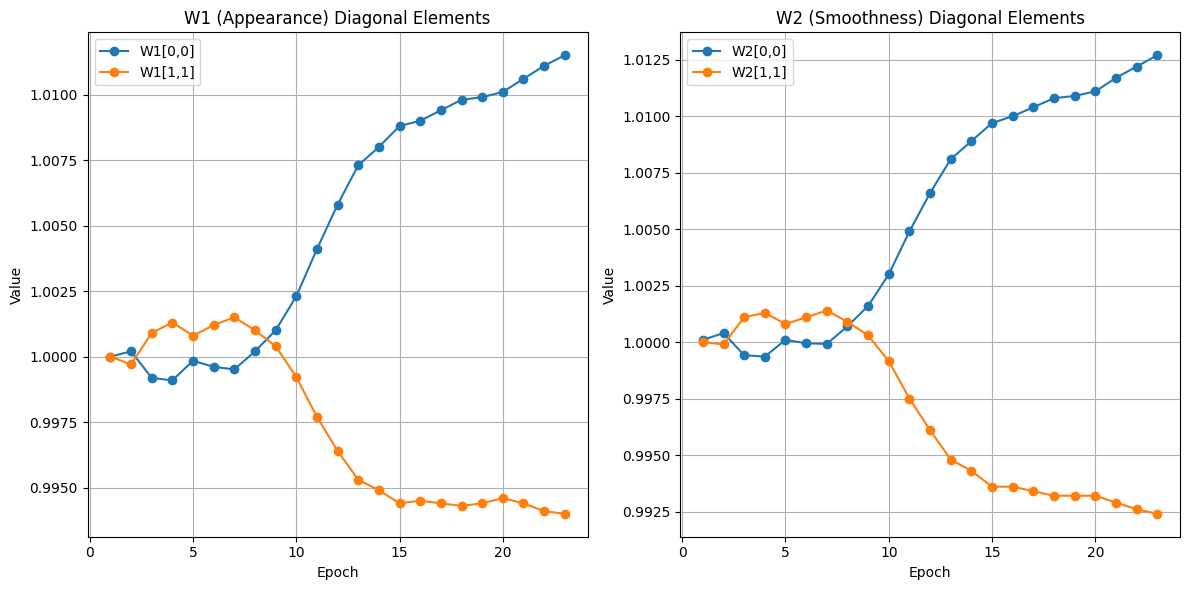

In [46]:
import re
import matplotlib.pyplot as plt


epochs = []
w1_00 = []
w1_11 = []
w2_00 = []
w2_11 = []

lines = lines.split('\n')
current_epoch = None
expect_w2 = False
expect_w1 = False
w2_data = []
w1_data = []

i = 0
while i < len(lines):
    line = lines[i]

    # Check for Epoch header
    epoch_match = re.search(r'Epoch\s+(\d+)/100:', line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    # Check for W2 line
    if 'W2(Smoothness) Off_Diag_Mean' in line:
        expect_w2 = True
        i += 1
        continue

    # Check for W1 line
    if 'W1(Appearance) Off_Diag_Mean' in line:
        expect_w1 = True
        i += 1
        continue

    if expect_w2:
        if line.startswith('tensor'):
            # This line and next line contain the tensor
            # Line format: tensor([[ A, B],
            row1 = line
            row2 = lines[i+1]

            # Extract numbers
            nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
            nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

            if len(nums1) >= 1 and len(nums2) >= 2:
                w2_00_val = float(nums1[0])
                w2_11_val = float(nums2[1]) # The second number in second row is 1,1
                w2_data.append((current_epoch, w2_00_val, w2_11_val))

            expect_w2 = False
            i += 1 # Skip next line
            continue

    if expect_w1:
        if line.startswith('tensor'):
            row1 = line
            row2 = lines[i+1]

            nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
            nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

            if len(nums1) >= 1 and len(nums2) >= 2:
                w1_00_val = float(nums1[0])
                w1_11_val = float(nums2[1])
                w1_data.append((current_epoch, w1_00_val, w1_11_val))

            expect_w1 = False
            i += 1
            continue

    i += 1

# Align data
plot_epochs = []
p_w1_00 = []
p_w1_11 = []
p_w2_00 = []
p_w2_11 = []

# w1_data and w2_data are lists of (epoch, val00, val11)
# Create a dictionary to merge
data_map = {}
for e, v00, v11 in w1_data:
    if e not in data_map: data_map[e] = {}
    data_map[e]['w1_00'] = v00
    data_map[e]['w1_11'] = v11

for e, v00, v11 in w2_data:
    if e not in data_map: data_map[e] = {}
    data_map[e]['w2_00'] = v00
    data_map[e]['w2_11'] = v11

sorted_epochs = sorted(data_map.keys())
for e in sorted_epochs:
    if 'w1_00' in data_map[e] and 'w2_00' in data_map[e]:
        plot_epochs.append(e)
        p_w1_00.append(data_map[e]['w1_00'])
        p_w1_11.append(data_map[e]['w1_11'])
        p_w2_00.append(data_map[e]['w2_00'])
        p_w2_11.append(data_map[e]['w2_11'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(plot_epochs, p_w1_00, label='W1[0,0]', marker='o')
plt.plot(plot_epochs, p_w1_11, label='W1[1,1]', marker='o')
plt.title('W1 (Appearance) Diagonal Elements')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(plot_epochs, p_w2_00, label='W2[0,0]', marker='o')
plt.plot(plot_epochs, p_w2_11, label='W2[1,1]', marker='o')
plt.title('W2 (Smoothness) Diagonal Elements')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('diagonal_elements_plot.png')

In [47]:
import pandas as pd
tp = pd.DataFrame(data_map)
tp.loc[:,range(1, 26, 5)]

,1,6,11,16,21
w1_00,1.0000,0.99961,1.0041,1.0090,1.0106
w1_11,1.0000,1.00120,0.9977,0.9945,0.9944
w2_00,1.0001,0.99995,1.0049,1.0100,1.0117
w2_11,1.0000,1.00110,0.9975,0.9936,0.9929


In [35]:
import pickle

trainer_result = {
    '_results': trainer._results,
    'best_epoch': trainer.best_epoch,
    'best_loss': trainer.best_loss,
    'train_loss': trainer.train_loss,
    'loss': trainer.loss,
}

with open(f'{RESULT_DIR}/trainer_result.pickle', 'wb') as f:
    pickle.dump(trainer_result, f)

In [36]:
result_file_path = f'{RESULT_DIR}/trainer_result.pickle'

with open(result_file_path, 'rb') as file:
    trainer_result = pickle.load(file)

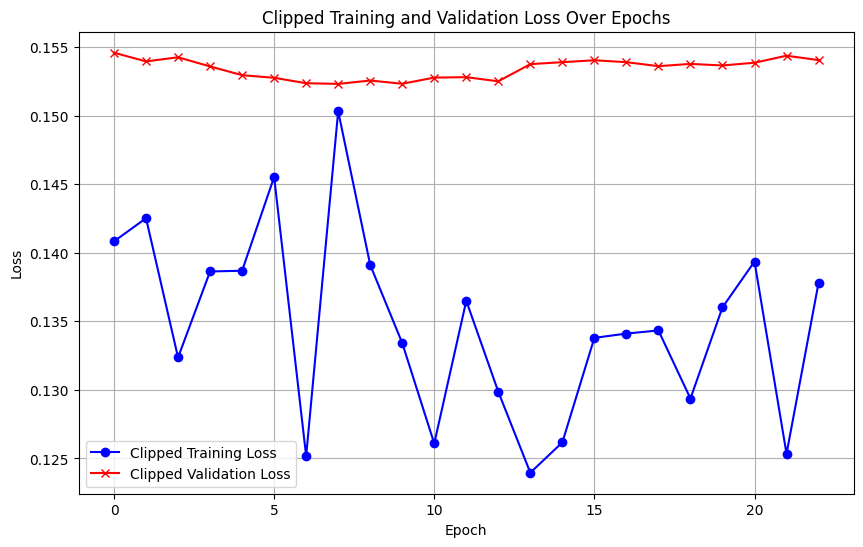

In [37]:
import matplotlib.pyplot as plt

train_losses = trainer_result['train_loss']
val_losses = trainer_result['loss']  # Assuming 'loss' contains the validation losses

max_loss = 1  # Set a threshold for maximum loss to visualize

clipped_train_losses = [min(loss, max_loss) for loss in train_losses]
clipped_val_losses = [min(loss, max_loss) for loss in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(clipped_train_losses, label='Clipped Training Loss', color='blue', marker='o')
plt.plot(clipped_val_losses, label='Clipped Validation Loss', color='red', marker='x')
plt.title('Clipped Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## ⭐ Evaluate

In [38]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched, collate_fn

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

!mkdir {RESULT_DIR}/Each_ckpt

### ⏭ Test score for all saved checkpoint.

In [39]:
# Check the last five best epochs
if not user:
    model = model_post
    checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
    for checkpoint_path in checkpoint_paths[-5:]:
        state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
        state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("\nLoad model at: ", state_dict_path)
        #trainer = CryoEMTrainerWithScheduler(model, train_dataset, criterion, optimizer, device,
        #              num_classes=NUM_CLASSES,
        #              lr_scheduler=scheduler, patience=ES_PATIENCE)
        #result = trainer.evaluate(test_loader)
        model.to(DEVICE)
        model.eval()
        mini_batch_size = 9  # Number of patches to process at once
        with torch.no_grad():
            idx, (test_image, dnzd_test_image, _, grid, _) = next(enumerate(test_dataset))
            inputs = test_image.to(DEVICE)
            pairwise = dnzd_test_image.to(device) if (dnzd_test_image is not None) else None
            num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
            patched_outputs = []

            for batch_idx in range(num_batches):
                start_idx = batch_idx * mini_batch_size
                end_idx = min(start_idx + mini_batch_size, inputs.size(0))
                patch_input = inputs[start_idx:end_idx].to(DEVICE)
                patch_pairwise = pairwise[start_idx:end_idx].to(DEVICE) if (pairwise is not None) else None
                output = model(patch_input, patch_pairwise)['out']
                patched_outputs.append(output.cpu())  # Move to CPU to conserve GPU memory

                del patch_input
                torch.cuda.empty_cache()
            outputs = torch.cat(patched_outputs).to(DEVICE)  # Move to CPU to conserve GPU memory
            del patched_outputs
            torch.cuda.empty_cache()
            preds = outputs.argmax(dim=1).unsqueeze(1).cpu().detach()  # Now preds will have shape [81, 1, 512, 512]

            ## Plotting
            micrograph = np.load(f"{IMAGE_DIR}/val/{val_filenames[idx][:-4]}.npy")
            label_path = f"{LABEL_DIR}/{val_filenames[idx][:-4]}.png"


            micrograph_copy = simple_micrograph_preprocessing(micrograph)
            #crop_amount = 128  # Amount cropped from each side of the label image
            mic_width, mic_height = micrograph_copy.shape[1], micrograph_copy.shape[0]

            # Calculate starting and ending indices for cropping the micrograph
            #start_x = int((mic_width - 3840) / 2)
            #end_x = start_x + 3840
            #start_y = int((mic_height - 3840) / 2)
            #end_y = start_y + 3840

            # Crop the micrograph
            cropped_micrograph = micrograph_copy
            pred_image = reconstruct_patched(preds, grid).float()

            _,ax = plt.subplots(figsize=(12, 12))
            ax.imshow(cropped_micrograph, cmap='gray')
            ax.imshow(pred_image.squeeze(), cmap='inferno', alpha=0.4)
            plt.show()
            ##

            filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
            pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
            save_image(pred_image, pred_path)

### ✅ Testing

In [40]:
# @markdown do testing
model = model_post
# dir_name = "unet_eb5_dice_CRF" # @param {type:"string"}
CHECKPOINT_PATH = RESULT_DIR

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint8.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint8.pt


In [41]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [42]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    np.random.seed(24)
    selected_filenames = np.random.choice(test_filenames, size=6, replace=False)
    print(selected_filenames)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=selected_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [43]:
evaluator = CryoEMEvaluator(
    model=model, device=DEVICE, metrics=['AP','iou'],
    num_classes=NUM_CLASSES)
print("ConvCRF validation result:")
result = evaluator.evaluate(loader=val_loader)
if not user:
    print("ConvCRF test result:")
    result = evaluator.evaluate(loader=test_loader)

ConvCRF validation result:
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
Iou by Class: [0.87696135 0.6413033 ]
Precision by Class: [0.9467171  0.74909097]
Recall by Class: [0.9224928 0.8167445]
Accuracy by Class: [0.8991468 0.8991468]
F1_score by Class: [0.93444794 0.7814561 ]


In [44]:
# @markdown ---
# @markdown time used
end_time = time.time()
print(f"End time recorded: {end_time}")

elapsed_time = end_time - start_time
elapsed_time = elapsed_time


hours = int(elapsed_time // 3600)
remaining_seconds = elapsed_time % 3600

minutes = int(remaining_seconds // 60)
seconds = round(remaining_seconds % 60, 3)

print(f"Time spend : {hours} h, {minutes} m, {seconds} s")


gpu_used = "L4" # @param ["CPU high", "T4", "T4 high", "L4"]
per_unit_cost_dict = {"L4" : 1.71, "T4 high" : 1.41, "T4" : 1.19, "CPU high" :  0.24}
per_unit_cost = per_unit_cost_dict[gpu_used]
print(f"unit price per hr {per_unit_cost}")

cost_units = per_unit_cost * elapsed_time / 3600

per_unit_US = 10.49 / 100

cost_price_US = cost_units * per_unit_US

print(f"unit cost : {round(cost_units, 4)}")
print(f"unit price US: {cost_price_US}")
print(f"unit price NTD: {cost_price_US * 30.76}")

End time recorded: 1767069406.6912081
Time spend : 0 h, 27 m, 24.014 s
unit price per hr 1.71
unit cost : 0.7809
unit price US: 0.08191709054632307
unit price NTD: 2.5197697052048977
